In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as font_manager
import seaborn as sns
import json

# Set style for matplotlib
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 24

In [7]:
soln_nums = [
    1, 2, 3, 4
]
titles = [
    'Plane waves', 'Radial waves', 'Hopf fibration', 'Random solution'
]

In [ ]:
ic_runs = [
    os.path.join('..', 'experiments', str(x)) for x in range(1698, 1718)
]

bc_runs = [ # pulling BC runs from here
    os.path.join('..', 'experiments', str(x)) for x in range(1562, 1582)
]

runs = ic_runs + bc_runs

assert len(runs) == 40, len(runs)

In [9]:
def interpolate_runs(dfs, n_points=1000, max_time=None, time_already_cum=False, log=False,
                     residual_threshold=1e-2):
    
    if log:
        max_time = np.exp(max_time)
    
    if not time_already_cum:
        cumtimes = [df['training_time'].cumsum().values for df in dfs]
    else:
        cumtimes = [df['training_time'].values for df in dfs]
    errors = [df['rel_l2_error'].values * 100 for df in dfs]

    # Apply residual mask: if a df has a 'residual' column, null out error values
    # for rows where residual >= threshold. This creates NaN gaps in the interpolation,
    # which matplotlib renders as breaks in the line.
    masked_errors = []
    for df, err in zip(dfs, errors):
        if 'best_val_pde_loss' in df.columns and 'best_val_div_loss' in df.columns:
            df['residual'] = np.sqrt((6*df['best_val_pde_loss'] + 2*df['best_val_div_loss'] ) / 8)
        if 'residual' in df.columns:
            err = err.copy().astype(float)
            err[df['residual'].values >= residual_threshold] = np.nan
            # print(np.isnan(err).sum())
        masked_errors.append(err)
    errors = masked_errors

    t_min = max(ct[0] for ct in cumtimes)  # latest start across seeds

    if max_time is not None:
        t_max = max_time
    else:
        t_max = min(ct[-1] for ct in cumtimes)  # earliest end (inner range)

    x = np.linspace(t_min, t_max, n_points)

    # Interpolate per seed, preserving NaN gaps caused by residual filtering.
    # np.interp ignores NaNs (treats them as valid), so we split each seed's
    # time-series into contiguous valid segments and interpolate each separately,
    # leaving x-positions that fall entirely within masked gaps as NaN.
    def interp_with_gaps(x_query, t, err):
        result = np.full(len(x_query), np.nan)
        valid = ~np.isnan(err)
        if not np.any(valid):
            return result
        # Find contiguous valid segments
        changes = np.diff(valid.astype(int))
        starts = list(np.where(changes == 1)[0] + 1)
        ends   = list(np.where(changes == -1)[0] + 1)
        if valid[0]:
            starts = [0] + starts
        if valid[-1]:
            ends = ends + [len(valid)]
        for s, e in zip(starts, ends):
            seg_t   = t[s:e]
            seg_err = err[s:e]
            if len(seg_t) < 1:
                continue
            # Only fill query points that fall within this segment's time range
            in_range = (x_query >= seg_t[0]) & (x_query <= seg_t[-1])
            result[in_range] = np.interp(x_query[in_range], seg_t, seg_err)
        return result

    interp_errors = np.stack([
        interp_with_gaps(x, ct, err)
        for ct, err in zip(cumtimes, errors)
    ])  # shape: (n_runs, n_points)

    n_runs = len(dfs)
    
    if log:
        x = np.log(x)
        # Suppress log-of-NaN warnings; NaNs propagate correctly
        with np.errstate(invalid='ignore'):
            interp_errors = np.log(interp_errors)

    # Mean/std ignore NaN so seeds with valid data still contribute at each point.
    # Points where ALL seeds are NaN remain NaN → plotted as breaks.
    y = np.nanmean(interp_errors, axis=0)
    y_err = np.nanstd(interp_errors, axis=0) / np.sqrt(n_runs)

    # Where every seed is NaN, force y/y_err back to NaN (nanmean returns NaN
    # for all-NaN slices but nanstd returns 0 — make both consistent).
    all_nan = np.all(np.isnan(interp_errors), axis=0)
    y[all_nan] = np.nan
    y_err[all_nan] = np.nan

    return x, y, y_err

/tmp/ipykernel_71206/2159059805.py:78: RuntimeWarning: Mean of empty slice
  y = np.nanmean(interp_errors, axis=0)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_71206/2159059805.py:78: RuntimeWarning: Mean of empty slice
  y = np.nanmean(interp_errors, axis=0)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_71206/2159059805.py:78: RuntimeWarning: Mean of empty slice
  y = np.nanmean(interp_errors, axis=0)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_71206/2159059805.py:78: Runt

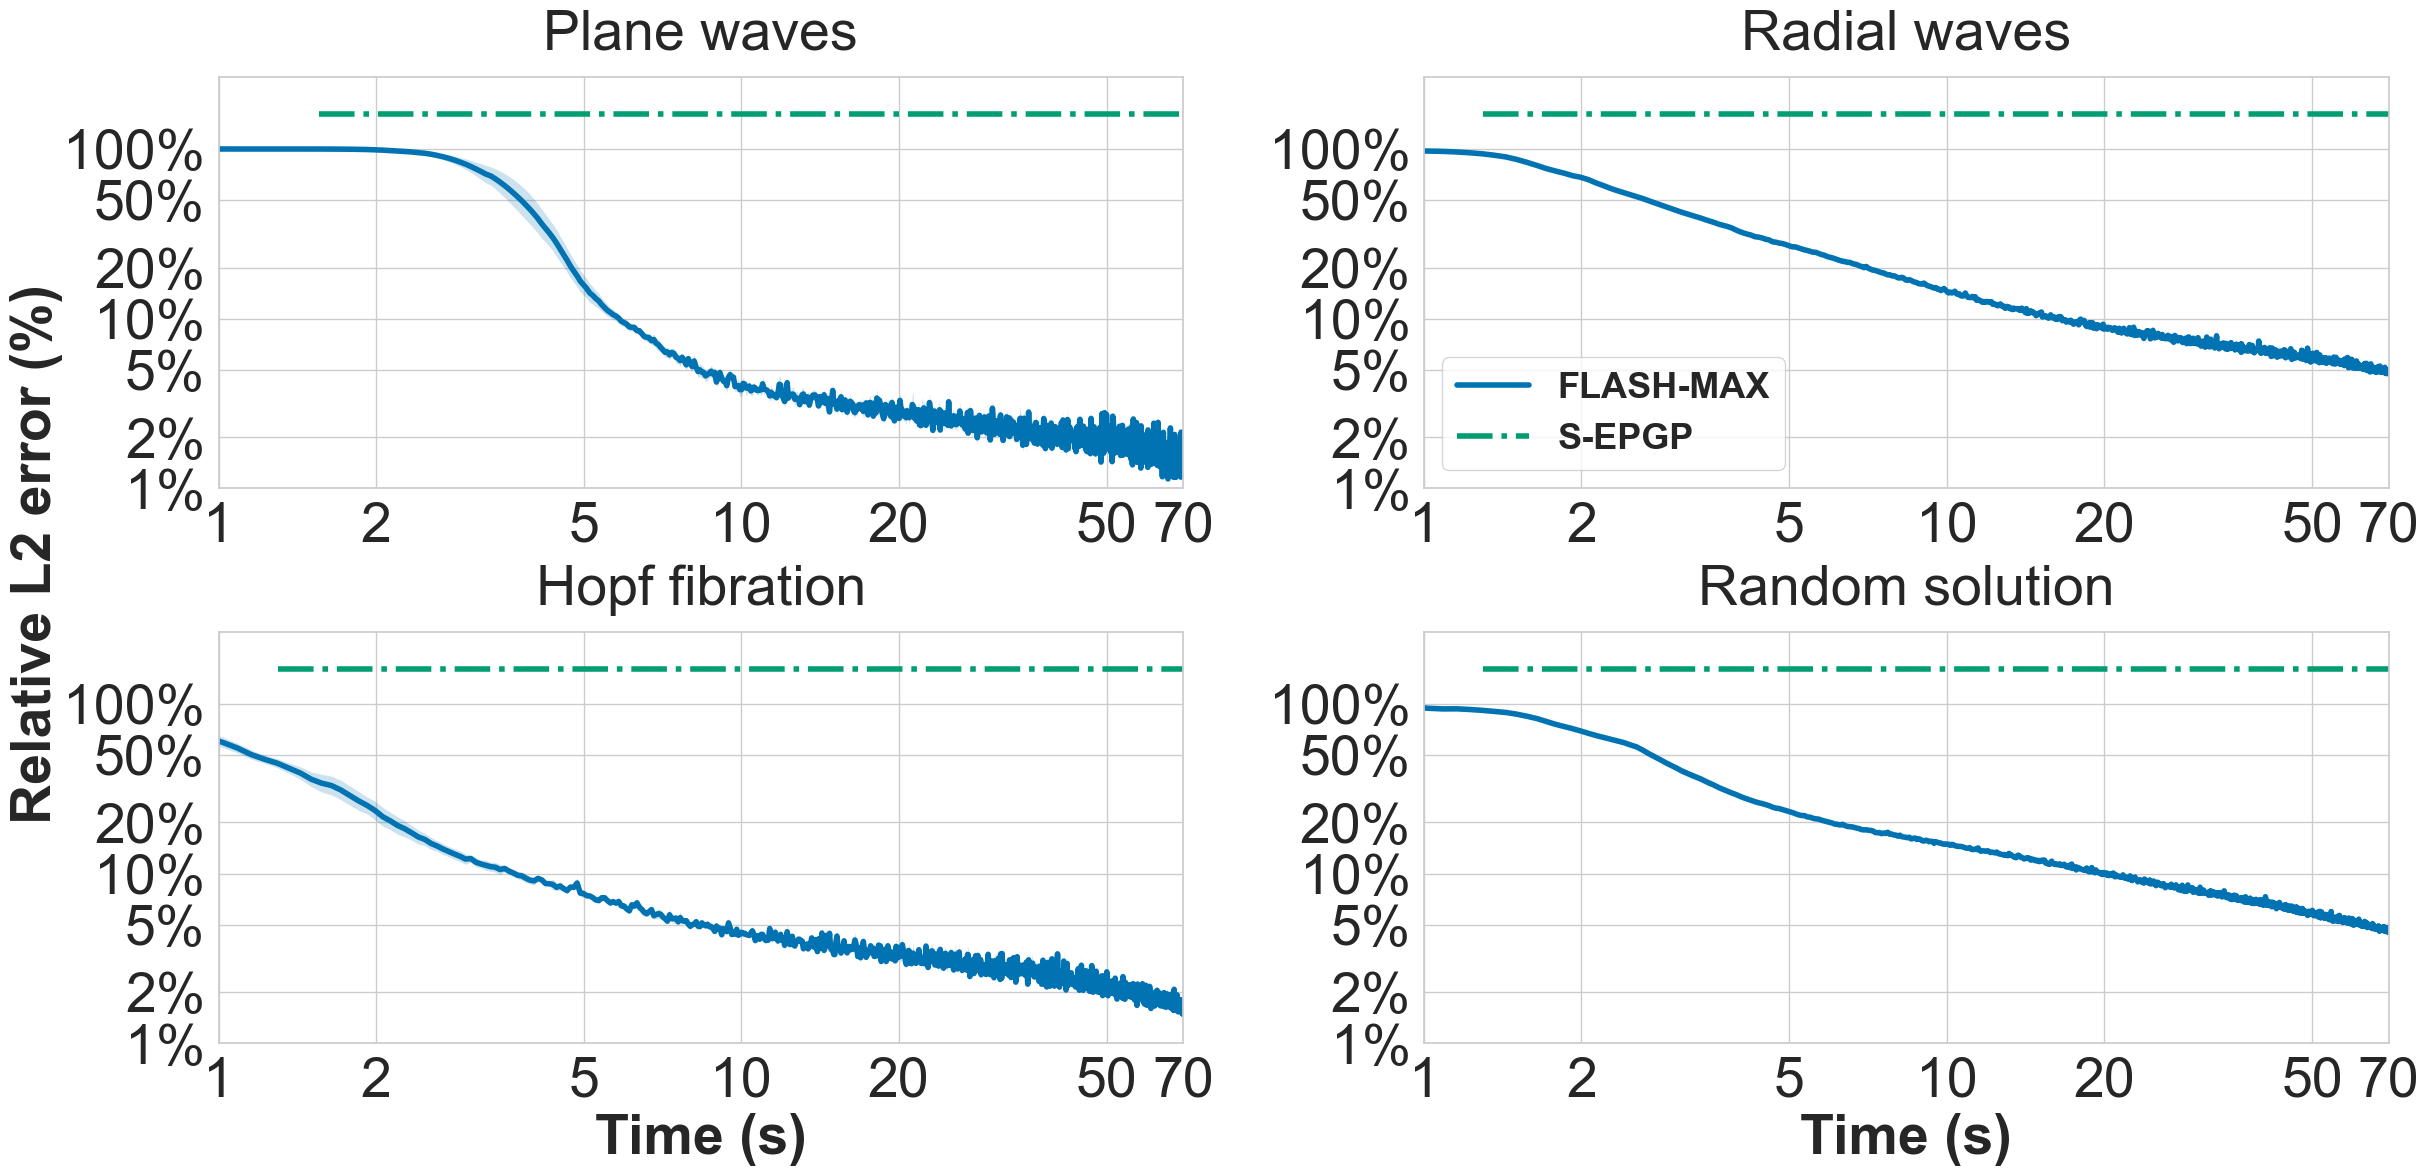

/tmp/ipykernel_71206/2159059805.py:78: RuntimeWarning: Mean of empty slice
  y = np.nanmean(interp_errors, axis=0)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_71206/2159059805.py:78: RuntimeWarning: Mean of empty slice
  y = np.nanmean(interp_errors, axis=0)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_71206/2159059805.py:78: RuntimeWarning: Mean of empty slice
  y = np.nanmean(interp_errors, axis=0)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_71206/2159059805.py:78: Runt

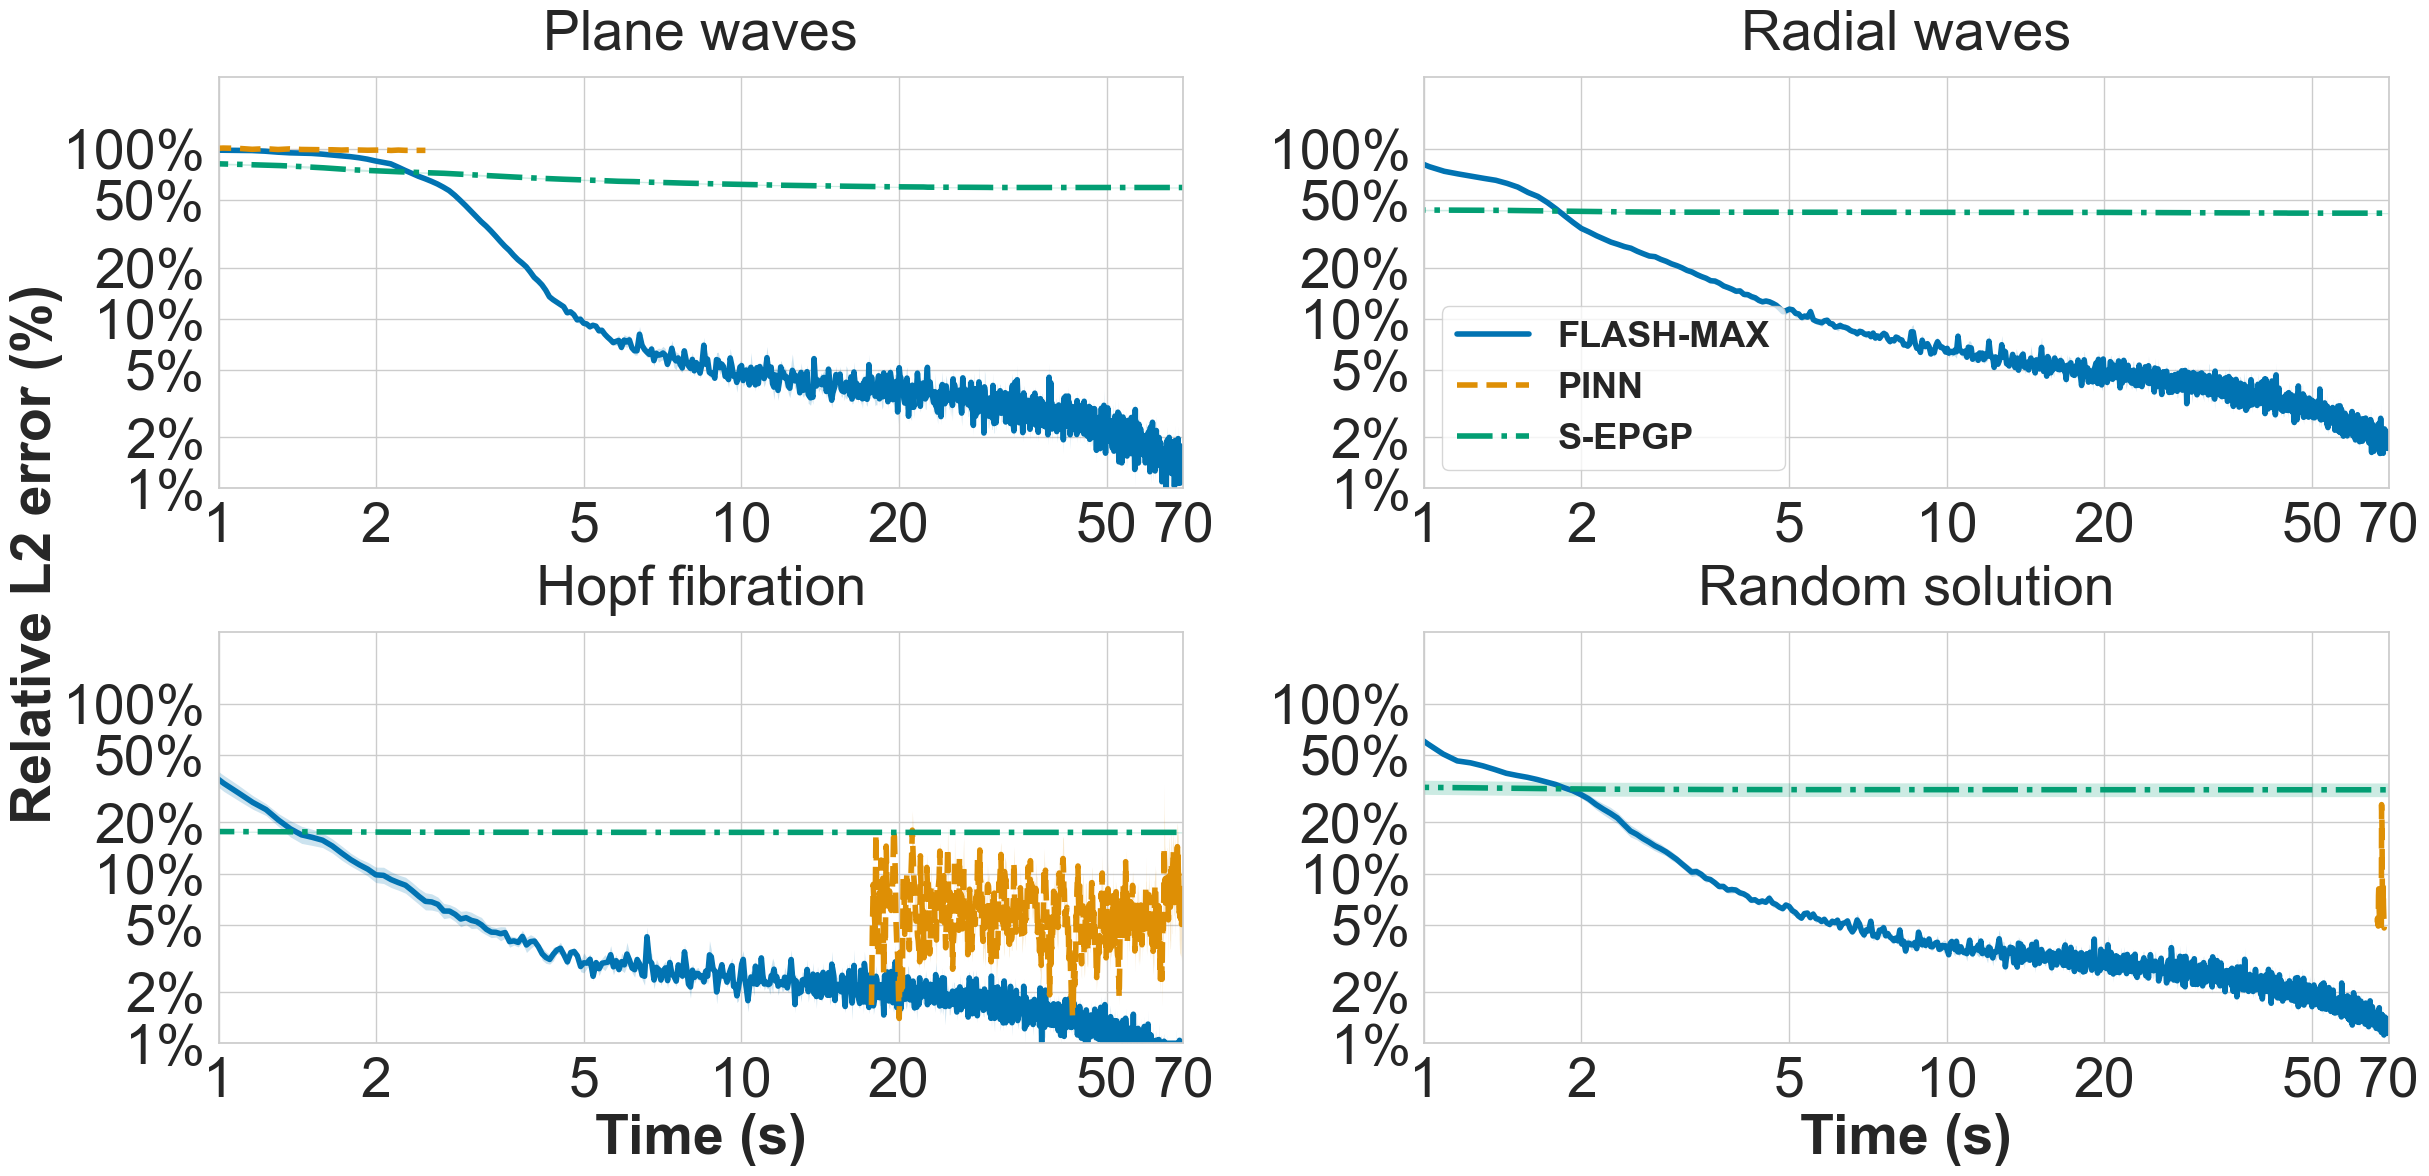

In [10]:
for add_bc in (True, False):

    exps = {
        1: [],
        2: [],
        3: [],
        4: []
    }

    settings = {
        'add_bc': add_bc,
        'use_cpu': False
    }

    legend_loc = 'lower left'#'upper right' if not settings['add_bc'] else 'lower left'

    for run in runs:
        keep_run = True
        hparams = json.load(open(os.path.join(run, 'hparams.json')))
        for k, v in settings.items():
            if hparams[k] != v:
                keep_run = False
                break
        if keep_run:
            exps[hparams['soln']].append(run)

    fs = 40
    lfs = 30
    lw = 4.0

    log = True

    max_time = 70
    max_err = 160

    if log:
        ytick_vals = np.array([1, 2, 5, 10, 20, 50, 100])
        xtick_vals = np.array([1, 2, 5, 10, 20, 50, 70])
        yticks = np.log(ytick_vals)
        xticks = np.log(xtick_vals)
        max_time = np.log(max_time)
        max_err = np.log(max_err)
    else:
        ytick_vals = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160])
        xtick_vals = np.array([0, 10, 20, 30, 40, 50, 60, 70])
        yticks = ytick_vals
        xticks = xtick_vals

    plt.rcParams.update({
        'font.size': fs,
        'axes.titlesize': fs,
        'axes.labelsize': fs,
        'xtick.labelsize': fs,
        'ytick.labelsize': fs,
        'legend.fontsize': lfs,
        'legend.title_fontsize': lfs,
        'figure.titlesize': fs
    })

    fig = plt.figure(figsize=(28, 28 * (max_err / max_time) * 0.75 / 2))  # taller than wide panels
    gs = gridspec.GridSpec(2, 2, width_ratios=[0.5, 0.5], hspace=0.35, wspace=0.25)

    colors = sns.color_palette("colorblind", 4)
    line_styles = ['-', '--', '-.', ':']

    axes = []

    for i, (soln_num, title) in enumerate(zip(soln_nums, titles)):
        row, col = divmod(i, 2)
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)

        exps_soln_num = exps[soln_num]
        logs = []
        
        for exp in exps_soln_num:
            df = pd.read_csv(os.path.join(exp, 'log.tsv'), sep='\t')
            if os.path.exists(os.path.join(exp, 'init_time.txt')):
                init_time = float(open(os.path.join(exp, 'init_time.txt')).read())
            else:
                init_time = 0.
            df['training_time'] += init_time # ok because it was cumulative, just translate everything
            logs.append(df)

        if   soln_num == 1: pinn_soln_name = 'planewave'
        elif soln_num == 2: pinn_soln_name = 'donut'
        elif soln_num == 3: pinn_soln_name = 'hopf'
        elif soln_num == 4: pinn_soln_name = 'random'

        if settings['add_bc']:
            pinn_logs = [
                pd.read_csv(
                    os.path.join(
                        'pinn_data', 'maxwell_bdy', pinn_soln_name, f'seed_{j}', 'log.tsv'
                    ), sep='\t')
                for j in range(1, 6)
            ]
        
            gp_logs = [
                pd.read_csv(
                    os.path.join(
                        'gp_data_l40s', 'GP_BDY_L40S', pinn_soln_name, f'seed_{j}', 'log.tsv'
                    ), sep='\t').rename(columns={'time_elapsed': 'training_time', 'best_val_rel_err': 'rel_l2_error'})
                for j in range(1, 6)
            ]
            
            fem_logs = [
                pd.read_csv(
                    os.path.join('fem_data', x), sep='\t'
                ).rename(columns={'rel_l2_val_error': 'rel_l2_error', 'pde_residual': 'residual'})
                for x in os.listdir('fem_data')
            ]
        else:
            pinn_logs = [
                pd.read_csv(
                    os.path.join(
                        'pinn_data', 'maxwell_nbdy', pinn_soln_name, f'seed_{j}', 'log.tsv'
                    ), sep='\t')
                for j in range(1, 6)
            ]
        
            gp_logs = [
                pd.read_csv(
                    os.path.join(
                        'gp_data_l40s', 'GP_NBDY_L40S', pinn_soln_name, f'seed_{j}', 'log.tsv'
                    ), sep='\t').rename(columns={'time_elapsed': 'training_time', 'best_val_rel_err': 'rel_l2_error'})
                for j in range(1, 6)
            ]

        assert len(logs) == 5
        assert len(pinn_logs) == 5
        assert len(gp_logs) == 5

        datas = [
            interpolate_runs(logs,      max_time=max_time, log=log),
            interpolate_runs(pinn_logs, max_time=max_time, time_already_cum=True, log=log),
            interpolate_runs(gp_logs, max_time=max_time, time_already_cum=True, log=log),
        ]
        if settings['add_bc']:
            datas.append(
                interpolate_runs(fem_logs, max_time=max_time, time_already_cum=True, log=log),
            )
        
        labels = ['FLASH-MAX', 'PINN', 'S-EPGP', 'FEM']

        # Gray reference line at 5%
        # thresh = 5 if not log else np.log(5)
        # ax.axhline(y=thresh, color='gray', linewidth=lw, linestyle='--', alpha=0.6, zorder=1)

        for color, line_style, data, label in zip(colors, line_styles, datas, labels):
            x_values, y_smooth, y_std = data
            if log:
                clip_val = np.log(1)
            else:
                clip_val = 0
            ax.fill_between(
                x_values,
                np.clip(y_smooth - y_std, clip_val, max_err),
                np.clip(y_smooth + y_std, clip_val, max_err),
                alpha=0.2, color=color, linewidth=0
            )
            ax.plot(
                x_values,
                np.clip(y_smooth, clip_val, max_err),
                linewidth=lw,
                color=color,
                linestyle=line_style,
                label=label
            )

        ax.set_title(title, pad=20)
        ax.set_ylim(0, max_err+0.5)
        ax.set_xlim(np.log(1) if log else 0, max_time)

        if row == 1:
            ax.set_xlabel("Time (s)", fontdict=dict(weight='bold'))
        else:
            ax.set_xlabel("")

        # if col == 0 and row == 1:
        #     ax.set_ylabel("", fontdict=dict(weight='bold'))
        # else:
        #     ax.set_ylabel("")
            
        if row == 0 and col == 1:
            handles, labels_ = axes[0].get_legend_handles_labels()
            if settings['add_bc']:
                handles = [handles[0], handles[2]]
                labels_ = [labels_[0], labels_[2]]
            ax.legend(
                handles,
                labels_,
                loc=legend_loc,
                frameon=True,
                prop = font_manager.FontProperties(size=lfs-4, weight='bold')
            )

        ax.set_yticks(yticks)  # yticks = np.log([20, 40, ..., 160])
        ax.set_yticklabels([f'{v:.0f}%' for v in ytick_vals])

        ax.set_xticks(xticks)  # xticks = np.log([10, 20, ..., 70])
        ax.set_xticklabels([f'{v:.0f}' for v in xtick_vals])

        # Make the plot area taller than wide via aspect — 'box' keeps axes box fixed
        # ax.set_aspect(max_time / max_err * 0.75, adjustable='box')  # <1 = taller than wide

    # if log:
    #     fig.suptitle(
    #         'Relative L2 validation error over time\n(w/ BC on NVIDIA L40S, average of 5 seeds), log-log scale',
    #         fontsize=fs, y=1.1
    #     )
    # else:
    #     fig.suptitle(
    #         'Relative L2 validation error over time\n(w/ BC on NVIDIA L40S, average of 5 seeds)',
    #         fontsize=fs, y=1.1
    #     )

    fig.text(
        0.06, 0.5,          # x position (left of subplots), y centered
        'Relative L2 error (%)',
        va='center',
        ha='center',
        rotation='vertical',
        fontsize=fs,
        fontweight='bold'   # if needed
    )

    plt.tight_layout(pad=1.0)
    plt.savefig(f"figs/timing_plots_bc_{settings['add_bc']}.pdf", bbox_inches='tight')
    plt.show()